## Reading in the Binary Data with RTxReadBin module from Rhode Schwarz Website
link: https://www.rohde-schwarz.com/sg/applications/working-with-acquired-waveform-data-in-python-application-card_56279-1165008.html

In [1]:
import pandas as pd
import numpy as np
import scipy as sp
import pyarrow.parquet as pq
import time
import matplotlib.pyplot as plt
import argparse
import csv
import pyarrow as pa 

In [4]:
import pkgutil
[m.name for m in pkgutil.iter_modules() if "rtx" in m.name.lower()] # finding the module names

['RS_RTxReadBin_copy', 'RSRTxReadBin', 'RS_RTxReadBin']

In [5]:
import RS_RTxReadBin as rb  # import the functionfrom RS_RTxReadBin.RTxReadBin import RTxReadBin  # import the function
from RS_RTxReadBin.RTxReadBin import RTxReadBin  # import the function

In [6]:
filename = '/Users/laloscola/ExternalDrive/magic_data_laboratory/RatioCheck2_Run1_2025-12-08_0_105129.Wfm.bin'

In [7]:
y, x , S = RTxReadBin(filename)  # or 
# x is time axis, y is voltage
print(y.shape, x.shape)

Found multichannel File, with channels: 1, 2. Using these!


(20000, 5000, 2) (20000,)


In [8]:
# The vertical data (y) is a NumPy array with a shape of [<record Length>, <# of acquisitions>, <# of active channels>]
# The horizontal data (x) is a 64-bit float NumPy array with a shape of [<record length>].

### Visualising .bin file

In [9]:
y1 = y[:,:,0] # picking only one channel 
y2 = y[:,:,1]

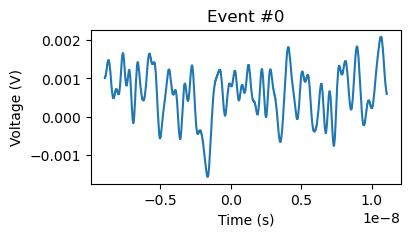

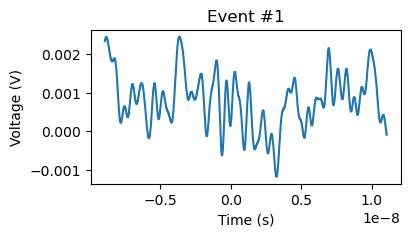

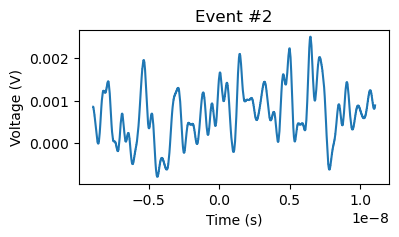

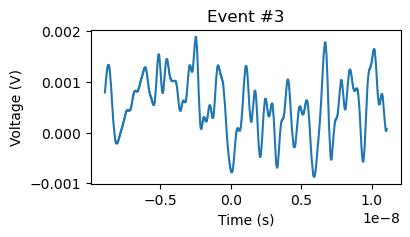

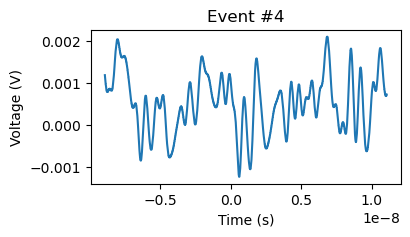

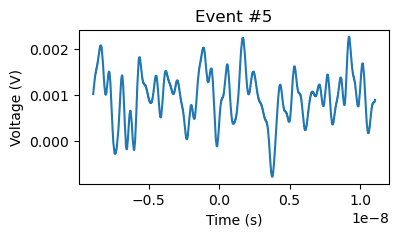

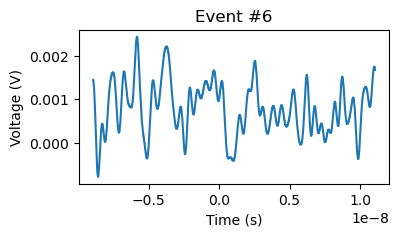

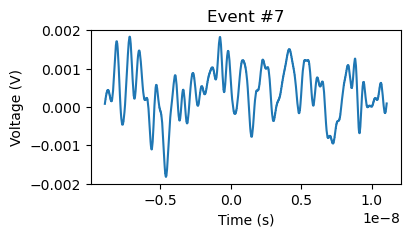

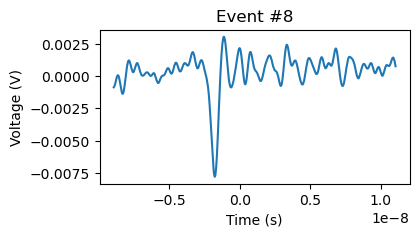

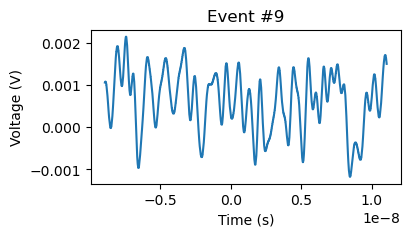

In [10]:
for i in range(0,10): # showing different acquisitions -> acq 8 is interesting
    y_i = y[:, i, 1]
    plt.figure(figsize=(4,2))
    plt.plot(x, y_i)
    plt.xlabel("Time (s)")
    plt.ylabel("Voltage (V)")
    plt.title(f'Event #{i}')
    plt.show()

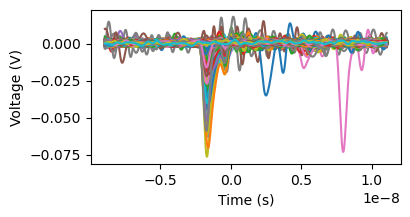

In [11]:
plt.figure(figsize=(4,2)) # plotting all acq's for channel 2
plt.plot(x, y2)
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.show()

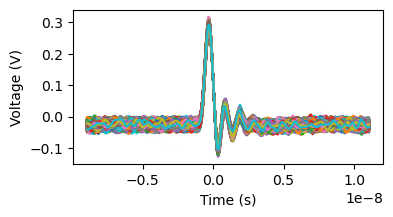

In [12]:
plt.figure(figsize=(4,2)) # plotting all acq's for channel 1
plt.plot(x, y1)
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.show()

### Inspecting and copying the RTxReadBin python file

In [13]:
print(rb.__file__)

/opt/homebrew/Caskroom/miniforge/base/envs/measureoscill/lib/python3.12/site-packages/RS_RTxReadBin/__init__.py


In [14]:
print(rb.RTxReadBin.__file__) # rb.RTx... is just the reader function in the file

/opt/homebrew/Caskroom/miniforge/base/envs/measureoscill/lib/python3.12/site-packages/RS_RTxReadBin/RTxReadBin.py


In [15]:
import os, shutil, RS_RTxReadBin

src = RS_RTxReadBin.__file__
dst = os.path.basename(src)   # will be "__init__.py"
print("Copying from", src, "to", dst)
shutil.copy(src, dst)

Copying from /opt/homebrew/Caskroom/miniforge/base/envs/measureoscill/lib/python3.12/site-packages/RS_RTxReadBin/__init__.py to __init__.py


'__init__.py'

In [16]:
import RSRTxReadBin
src = RSRTxReadBin.__file__
dst = os.path.basename(src)   # will be "__init__.py"
print("Copying from", src, "to", dst)
shutil.copy(src, dst)

Copying from /opt/homebrew/Caskroom/miniforge/base/envs/measureoscill/lib/python3.12/site-packages/RSRTxReadBin/__init__.py to __init__.py


'__init__.py'

In [17]:
import RS_RTxReadBin, pkgutil, os

pkg_path = os.path.dirname(RS_RTxReadBin.__file__)
print("Package path:", pkg_path)

# list all modules/files in the package
for m in pkgutil.iter_modules([pkg_path]):
    print(m.name)


Package path: /opt/homebrew/Caskroom/miniforge/base/envs/measureoscill/lib/python3.12/site-packages/RS_RTxReadBin
RTxReadBin


In [18]:
import importlib

mod = importlib.import_module(f"RS_RTxReadBin.RTxReadBin")  # replace m.name with the actual name
print(mod.__file__)


/opt/homebrew/Caskroom/miniforge/base/envs/measureoscill/lib/python3.12/site-packages/RS_RTxReadBin/RTxReadBin.py


In [19]:
import shutil

src = mod.__file__
shutil.copy(src, "RS_RTxReadBin_impl.py")  # choose a name


'RS_RTxReadBin_impl.py'

### Writing converter from csv to pandas df for load_df to use

#### Tasks:
- y,x,S = RTxReadBin(filename) reads the bin file and outputs np.arrays

In [20]:
print(f'y: {type(y), y.shape, y.dtype, y.ndim, y.size} \nx:{type(x), x.shape, x.dtype, x.ndim, x.size}\nS: {type(S)}')

y: (<class 'numpy.ndarray'>, (20000, 5000, 2), dtype('float32'), 3, 200000000) 
x:(<class 'numpy.ndarray'>, (20000,), dtype('float64'), 1, 20000)
S: <class 'dict'>


In [21]:
for k in list(S.keys())[:80]:
    print(k, "->", S[k])

SourceType -> eRS_SIGNAL_SOURCE_TYPE_SOURCE
Resolution -> 1e-12
RecordLength -> 20000.0
HWRecordLength -> 20000.0
TriggerOffset -> 0.0
RescaleCenterTime -> 1.04e-09
DecimationMode -> eRS_DECIMATION_MODE_SAMPLE
TraceArithmetics -> eRS_TRACE_ARITHMETICS_SINGLE
TraceType -> eRS_TRACE_TYPE_NORMAL
BaseUnit -> eRS_UNIT_LEVEL_V
BaseUnitRelative -> eRS_ONOFF_OFF
Impedance -> 50.0
XStart -> -8.94e-09
XStop -> 1.106e-08
SignalRecordLength -> 20000.0
HardwareXStart -> -8.94e-09
HardwareXStop -> 1.106e-08
SignalHardwareRecordLength -> 20000.0
AdjustedResolutionBW -> 0.0
NoiseBandwidth -> 0.0
InterleavedTraceCount -> 1.0
ValueType -> eRS_SIGNAL_VALUE_TYPE_COMPLETELY_FINITE_DEFINED
NofQuantisationLevels -> 64768.0
DecimationFactor -> 0.005
TOADone -> eRS_ONOFF_ON
ISO_TRG -> 111.0
SC_POST -> 78760039516000.0
SC_TRG -> 78760039515090.0
SignalResolution -> 1e-12
LeadingSettlingSamples -> 0.0
TimeScale -> 2e-09
ReferencePoint -> 44.7
RescaleCenterPoint -> 49.9
VerticalPosition -> 2.94
VerticalScale -> 0

In [22]:
for k in (list(S.keys())[:80]):
    if k == 'Resolution': 
        print(f'{k} -> {S[k]}')
    if  k == 'RecordLength': 
        print(f'{k} -> {S[k]}')
    if k == 'Timestamps': 
        print(f'Number of Acquisitions: {len(S[k])}\nTimestamps recorded: Yes') 

Resolution -> 1e-12
RecordLength -> 20000.0
Number of Acquisitions: 5000
Timestamps recorded: Yes


In [23]:
import RS_RTxReadBin as rb  
from RS_RTxReadBin.RTxReadBin import RTxReadBin  
import os 

In [30]:
def converter_binary_to_df(filepath, show_info = True): 
    '''Should give pandas dataframe of the form: 
       event_id | time_axis | Ch_1_volt | Ch_2_volt |
    '''
    if os.path.exists(filepath): # checks existence of path
        root, ext = os.path.splitext(filepath)
        ext = ext.lower()
    
        if ext == '.bin': # checking file type
            y, x , S = RTxReadBin(filepath) # x is time axis, y is voltage, S is header information
            if show_info:
                for k in (list(S.keys())[:80]):
                    if k == 'Resolution': 
                        print(f'{k} -> {S[k]}')
                    if  k == 'RecordLength': 
                        print(f'{k} -> {S[k]}')
                    if k == 'Timestamps': 
                        print(f'Number of Acquisitions: {len(S[k])}\nTimestamps recorded: Yes')  # prints information about time resolution and recordlength           
        if ext == '.csv': 
            print('CSV file given: use meas_finalcode_camera.ipynb function convert#channels_csv_to_csv_and_parquet instead')
        if ext not in ('.bin', '.csv'): 
            print(f'Unknown filetype: {ext}')

        # now check for number of channels in y 
        
        n_samples, n_acq, n_ch = y.shape # how many samples per acquisition, acquisitions, channels
        print(f'Number of channels given: {n_ch}')

        # broadcast x over acquisitions
        timestamps = np.tile(x[:, None], (1, n_acq))          # (n_samples, n_acq)
        event_ids = np.tile(np.arange(n_acq)[None, :], (n_samples, 1))  # (n_samples, n_acq)
        
        # flatten everything
        timestamps_flat = timestamps.ravel()   # length n_samples * n_acq
        event_ids_flat = event_ids.ravel()
        
        ch1_flat = y[:, :, 0].ravel()          # adapt indices to your channel mapping
        ch2_flat = y[:, :, 1].ravel()
        
        df = pd.DataFrame({
            "event_id": event_ids_flat,
            "timestamp": timestamps_flat,
            "Ch_1": ch1_flat,
            "Ch_2": ch2_flat,
        })

        return df     

In [39]:
df = converter_binary_to_df(filename)

Found multichannel File, with channels: 1, 2. Using these!


Resolution -> 1e-12
RecordLength -> 20000.0
Number of Acquisitions: 5000
Timestamps recorded: Yes
Number of channels given: 2


In [40]:
from functions_meas_finalcode import main_ratio_and_plots

In [42]:
main_ratio_and_plots(df, min_thresh=-0.006, show_only_camera=False) # thresh looks promising for this measurement

There are: 371 interesting events, that match the used threshold
The percentage of interesting events to empty events is: 8.015%


8.014689997839707

In [57]:
from functions_meas_finalcode import main_jitter_plot_and_fwhm
from functions_meas_finalcode import main_amplitude_spectrum
from functions_meas_finalcode import main_main

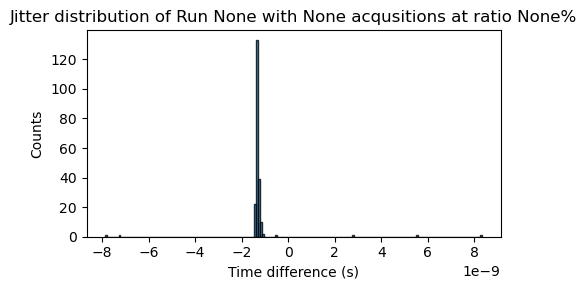

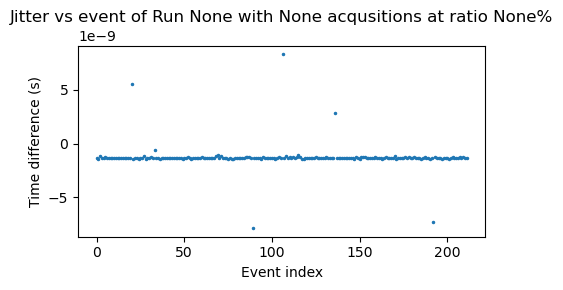

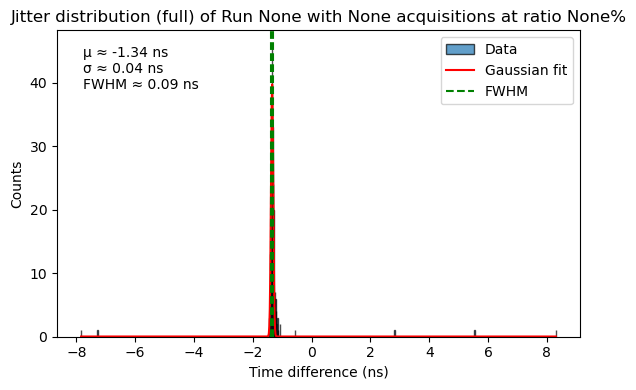

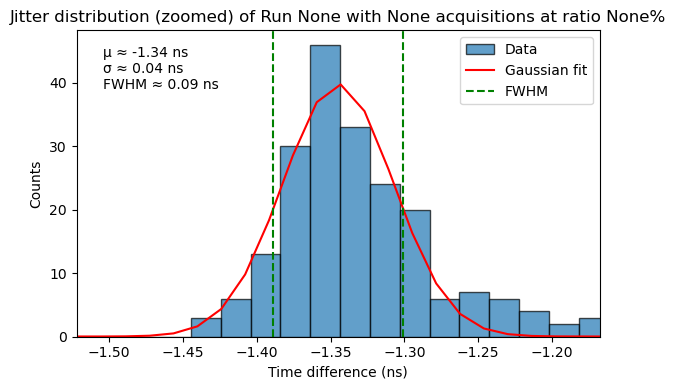

In [52]:
main_jitter_plot_and_fwhm(df, bins_fit=800)

The mean area is: 1.408767343600101e-11 Vs


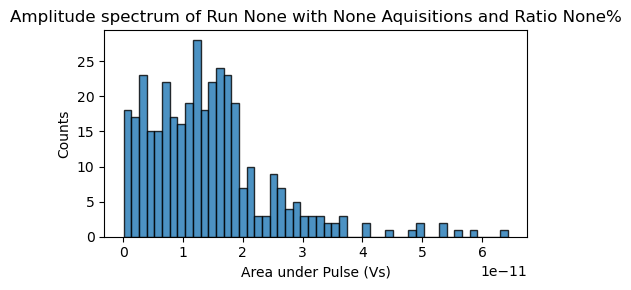

In [51]:
main_amplitude_spectrum(df, min_thresh=-0.006, bins=50)

### Final Phase: code for bigger data

### Tasks for Monday:
1. take 1mio or 500_000 acquisitions for -> quickly calculate the time it takes for it
    - signal
    - background
2. decide measurement resolution
3. write better code for the deltas calculation -> see Thomas' last email
4. write chunked code
   

#### Idea: 
- iterate over binary_to_df_converter (output df)
- histogram code input is df
- make hist code return the histogram

-> check bins, edges of hists per chunk (need to fix the edges, otherwise conflict between chunks)

binary to chunk_df $\rightarrow$ chunk_df into chunk_hists $\rightarrow$ save into big_hist $\rightarrow$ plot in the end

In [38]:
def idea_code(file, chunk):
    for i in len(file/chunk):
        df_chunk = chunk_converter_binary_to_df(file, False, chunk_nr = i)
        main_ratio_and_plots(df, show_all_channels=False, show_only_camera=False, min_thresh=-0.006)

        big_hist1, big_hist_events_vs_jitter, big_hist_gauss, big_hist_gauss_zoom = [], [], [], [] 
        (hist_1, hist_events_vs_jitter, hist_gauss, hist_gauss zoom) = main_jitter_plot_and_fwhm # maybe one only needs to collect the big_deltas

        big_hist1 += hist_1 
        big_hist_events_vs_jitter ...
        

SyntaxError: invalid non-printable character U+00A0 (1992847082.py, line 6)

In [34]:
def chunk_converter_binary_to_df(filepath, show_info = True, chunk_size = 500_000): 
    '''Should give pandas dataframe of the form: 
       event_id | time_axis | Ch_1_volt | Ch_2_volt |

       Returns chunked pandas dataframes
    '''
    if os.path.exists(filepath): # checks existence of path
        root, ext = os.path.splitext(filepath)
        ext = ext.lower()
    
        if ext == '.bin': # checking file type
            y, x , S = RTxReadBin(filepath) # x is time axis, y is voltage, S is header information
            if show_info:
                for k in (list(S.keys())[:80]):
                    if k == 'Resolution': 
                        print(f'{k} -> {S[k]}')
                    if  k == 'RecordLength': 
                        print(f'{k} -> {S[k]}')
                    if k == 'Timestamps': 
                        print(f'Number of Acquisitions: {len(S[k])}\nTimestamps recorded: Yes')  # prints information about time resolution and recordlength           
        if ext == '.csv': 
            print('CSV file given: use meas_finalcode_camera.ipynb function convert#channels_csv_to_csv_and_parquet instead')
        if ext not in ('.bin', '.csv'): 
            print(f'Unknown filetype: {ext}')

        # now check for number of channels in y 
        
        n_samples, n_acq, n_ch = y.shape # how many samples per acquisition, acquisitions, channels
        print(f'Number of channels given: {n_ch}')

        # broadcast x over acquisitions
        timestamps = np.tile(x[:, None], (1, n_acq))          # (n_samples, n_acq)
        event_ids = np.tile(np.arange(n_acq)[None, :], (n_samples, 1))  # (n_samples, n_acq)
        
        # flatten everything
        timestamps_flat = timestamps.ravel()   # length n_samples * n_acq
        event_ids_flat = event_ids.ravel()
        
        ch1_flat = y[:, :, 0].ravel()          # adapt indices to your channel mapping
        ch2_flat = y[:, :, 1].ravel()
        
        df = pd.DataFrame({
            "event_id": event_ids_flat,
            "timestamp": timestamps_flat,
            "Ch_1": ch1_flat,
            "Ch_2": ch2_flat,
        })

        return df     